# **Logistic Regression with KFold Cross-Validation fotr Binary Classification**

# E-Commerce Shipping Dataset Overview

The **E-Commerce Shipping** dataset provides shipping and delivery data for products ordered through an e-commerce platform. The goal is to **predict whether a product shipment is delivered on time**, using information related to the shipment process, customer interaction, and product details.

## Source:

Available on Kaggle as a public dataset for classification modeling and EDA:

* [Kaggle Dataset Page](https://www.kaggle.com/datasets/prachi13/customer-analytics)

---

# Target Variable:

* **Reached.on.Time\_Y.N** *(binary)*: Whether the shipment was delivered on time (`0` = Yes, `1` = No)

---

### Features:

| Column Name            | Description                                            | Data Type         |
| ---------------------- | ------------------------------------------------------ | ----------------- |
| ID                     | Unique identifier for each product shipment            | *String*          |
| Warehouse\_block       | Zone of the warehouse handling the shipment            | *Categorical*     |
| Mode\_of\_Shipment     | Shipping method used (`Ship`, `Flight`, `Road`)        | *Categorical*     |
| Customer\_care\_calls  | Number of customer care calls made about the shipment  | *Numeric (int)*   |
| Customer\_rating       | Customer's rating for the service (1 to 5)             | *Numeric (int)*   |
| Cost\_of\_the\_Product | Cost of the product ordered                            | *Numeric (int)*   |
| Prior\_purchases       | Number of prior purchases made by the customer         | *Numeric (int)*   |
| Product\_importance    | Perceived product importance (`low`, `medium`, `high`) | *Categorical*     |
| Gender                 | Gender of the customer (`M`, `F`)                      | *Categorical*     |
| Discount\_offered      | Discount applied to the product                        | *Numeric (int)*   |
| Weight\_in\_gms        | Weight of the product in grams                         | *Numeric (int)*   |
| Reached.on.Time\_Y.N   | Delivery status (`0` = On time, `1` = Delayed)         | **Binary Target** |




In [1]:
import pandas as pd


df=pd.read_csv('ecom_shipping_v1.csv')
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


# **Checking for missing values**

In [3]:
df.isna().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [4]:
(df == '').sum()


,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [5]:
df.apply(lambda x: x.astype(str).str.lower().isin(['none', 'null', 'na','?'])).sum()


,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


# **Displaying unique values of categorical columns**

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {unique_vals}")
    print('------------------------------------------------')

Warehouse_block (5 unique): ['D' 'F' 'A' 'B' 'C']
------------------------------------------------
Mode_of_Shipment (3 unique): ['Flight' 'Ship' 'Road']
------------------------------------------------
Product_importance (3 unique): ['low' 'medium' 'high']
------------------------------------------------
Gender (2 unique): ['F' 'M']
------------------------------------------------


# **Count plot for target variable**

Reached.on.Time_Y.N
1    0.596691
0    0.403309
Name: proportion, dtype: float64


<Axes: xlabel='Reached.on.Time_Y.N'>

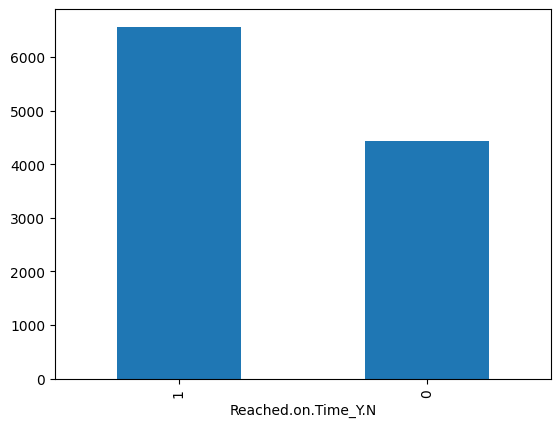

In [6]:
print(df['Reached.on.Time_Y.N'].value_counts(normalize=True))
df['Reached.on.Time_Y.N'].value_counts().plot(kind='bar')

# **Optimal Number of KFolds (value of K) using Using Logistic Regression and Categorical features: Integer Encoded**

We use **StratifiedKFold** to ensure that each fold has approximately the same proportion of class labels as the full dataset, and we evaluate fold counts in the range **3 to 7** to identify the optimal choice.

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Separate features and target
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)  # Features (excluding ID and target)
y = df['Reached.on.Time_Y.N']                       # Target column


# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

fold_values = [3,4, 5,6,7 ]  # Varying K-Fold splits


# Initialize metrics dictionary
metrics_kfold = {
    'folds': [],
    'Train Accuracy': [], 'Test Accuracy': [],
    'Train Precision': [], 'Test Precision': [],
    'Train Recall': [], 'Test Recall': [],
    'Train F1': [], 'Test F1': [],
    'Train AUC': [], 'Test AUC': []
}

# Loop over different fold counts
for n_folds in fold_values:
    train_acc, test_acc = [], []
    train_prec, test_prec = [], []
    train_rec, test_rec = [], []
    train_f1, test_f1 = [], []
    train_auc, test_auc = [], []

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(X, y):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Encode + Scale
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        scaler = StandardScaler()

        X_train = X_train_raw.copy()
        X_test = X_test_raw.copy()

        X_train[categorical_cols] = encoder.fit_transform(X_train_raw[categorical_cols])
        X_test[categorical_cols] = encoder.transform(X_test_raw[categorical_cols])

        X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

        # Train LR
        model= LogisticRegression()
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

        train_prec.append(precision_score(y_train, y_train_pred, zero_division=0))
        test_prec.append(precision_score(y_test, y_test_pred, zero_division=0))

        train_rec.append(recall_score(y_train, y_train_pred, zero_division=0))
        test_rec.append(recall_score(y_test, y_test_pred, zero_division=0))

        train_f1.append(f1_score(y_train, y_train_pred, zero_division=0))
        test_f1.append(f1_score(y_test, y_test_pred, zero_division=0))

        train_auc.append(roc_auc_score(y_train, y_train_prob))
        test_auc.append(roc_auc_score(y_test, y_test_prob))

    # Store average metrics
    metrics_kfold['folds'].append(n_folds)
    metrics_kfold['Train Accuracy'].append(np.mean(train_acc))
    metrics_kfold['Test Accuracy'].append(np.mean(test_acc))
    metrics_kfold['Train Precision'].append(np.mean(train_prec))
    metrics_kfold['Test Precision'].append(np.mean(test_prec))
    metrics_kfold['Train Recall'].append(np.mean(train_rec))
    metrics_kfold['Test Recall'].append(np.mean(test_rec))
    metrics_kfold['Train F1'].append(np.mean(train_f1))
    metrics_kfold['Test F1'].append(np.mean(test_f1))
    metrics_kfold['Train AUC'].append(np.mean(train_auc))
    metrics_kfold['Test AUC'].append(np.mean(test_auc))


import pandas as pd

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_kfold)

# Optional: round for readability
metrics_df = metrics_df.round(4)

# Print all metrics
metrics_df[['folds','Test Accuracy','Test Precision','Test Recall','Test F1','Test AUC']]



,folds,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,3,0.6385,0.7028,0.6828,0.6925,0.7201
1,4,0.6411,0.7053,0.6843,0.6945,0.7206
2,5,0.6425,0.7066,0.6854,0.6957,0.7203
3,6,0.6392,0.7032,0.6838,0.6933,0.7205
4,7,0.6390,0.7036,0.6822,0.6926,0.7203


### **Observations**
* Performance is almost identical across all folds, showing stable results with integer-encoded categorical features.
* Best test accuracy is observed at **5 folds**, but the improvement over other folds is marginal, showing that changing the number of folds does not significantly affect accuracy.

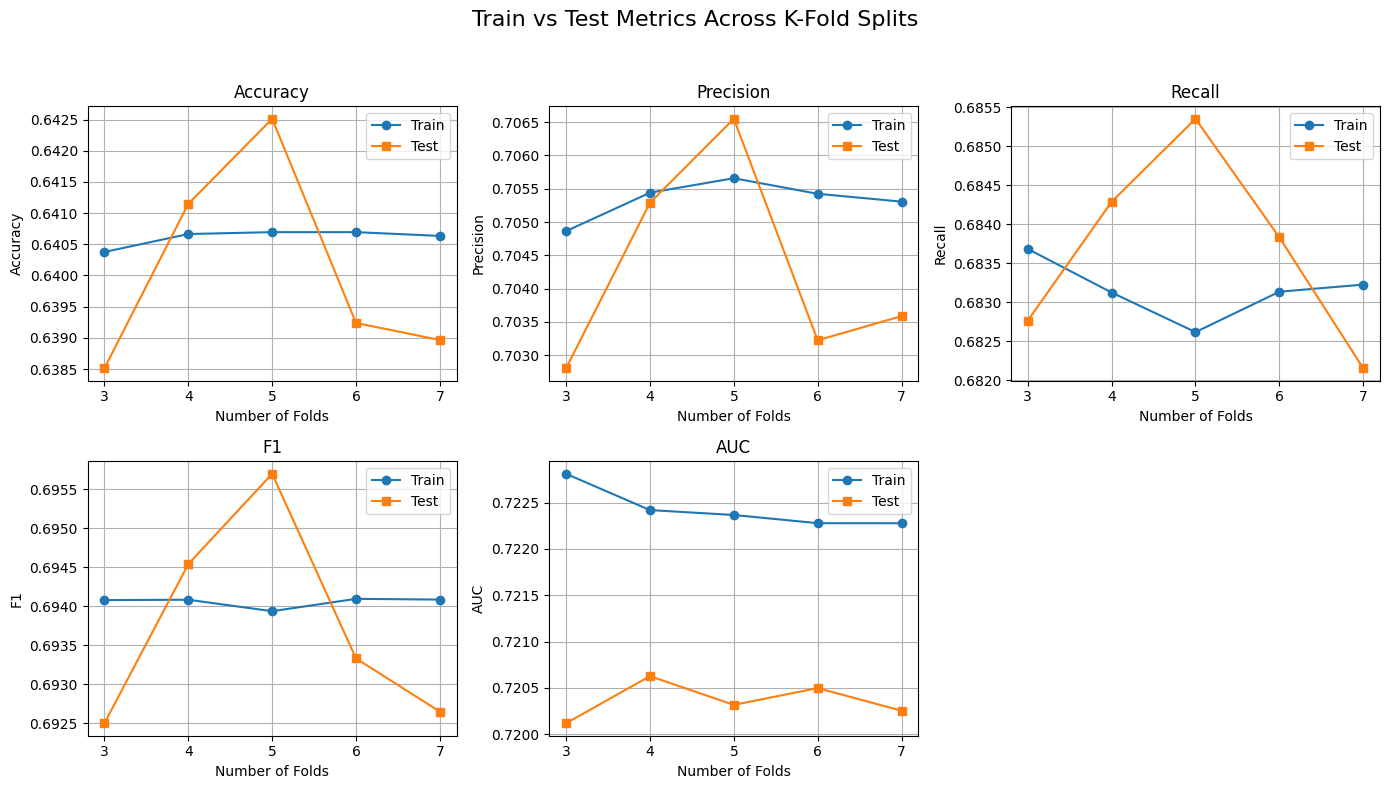

In [21]:
# Plotting function
def plot_all_metrics_in_grid(metrics, x_values):
    metric_names = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, name in enumerate(metric_names):
        ax = axes[i]
        ax.plot(x_values, metrics[f"Train {name}"], marker='o', label='Train')
        ax.plot(x_values, metrics[f"Test {name}"], marker='s', label='Test')
        ax.set_title(name)
        ax.set_xlabel("Number of Folds")
        ax.set_ylabel(name)
        ax.grid(True)
        ax.legend()

    if len(metric_names) < len(axes):
        axes[-1].axis("off")

    fig.suptitle("Train vs Test Metrics Across K-Fold Splits", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Call the plotting function
plot_all_metrics_in_grid(metrics_kfold, metrics_kfold['folds'])

### **Observations**
We select 5-fold cross validation as it performs slightly better than the other fold settings, even though the difference is marginal.

# **Optimal Number of KFolds (value of K) using Using Logistic Regression and Categorical features: One Hot Encoded**

We use **StratifiedKFold** to ensure that each fold has approximately the same proportion of class labels as the full dataset, and we evaluate fold counts in the range **3 to 7** to identify the optimal choice.

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Separate features and target
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)  # Features (excluding ID and target)
y = df['Reached.on.Time_Y.N']                       # Target column


# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

fold_values = [3,4, 5,6,7 ]  # Varying K-Fold splits


# Initialize metrics dictionary
metrics_kfold = {
    'folds': [],
    'Train Accuracy': [], 'Test Accuracy': [],
    'Train Precision': [], 'Test Precision': [],
    'Train Recall': [], 'Test Recall': [],
    'Train F1': [], 'Test F1': [],
    'Train AUC': [], 'Test AUC': []
}

# Loop over different fold counts
for n_folds in fold_values:
    train_acc, test_acc = [], []
    train_prec, test_prec = [], []
    train_rec, test_rec = [], []
    train_f1, test_f1 = [], []
    train_auc, test_auc = [], []

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(X, y):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler() # drop='first'
        encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

        # One-hot encode categorical columns
        X_train_cat = encoder.fit_transform(X_train_raw[categorical_cols])
        X_test_cat = encoder.transform(X_test_raw[categorical_cols])

        # Scale numerical columns
        X_train_num = scaler.fit_transform(X_train_raw[numerical_cols])
        X_test_num = scaler.transform(X_test_raw[numerical_cols])

        # Combine numeric + categorical
        X_train = np.hstack([X_train_num, X_train_cat])
        X_test = np.hstack([X_test_num, X_test_cat])



        # Train LR
        model= LogisticRegression()
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

        train_prec.append(precision_score(y_train, y_train_pred, zero_division=0))
        test_prec.append(precision_score(y_test, y_test_pred, zero_division=0))

        train_rec.append(recall_score(y_train, y_train_pred, zero_division=0))
        test_rec.append(recall_score(y_test, y_test_pred, zero_division=0))

        train_f1.append(f1_score(y_train, y_train_pred, zero_division=0))
        test_f1.append(f1_score(y_test, y_test_pred, zero_division=0))

        train_auc.append(roc_auc_score(y_train, y_train_prob))
        test_auc.append(roc_auc_score(y_test, y_test_prob))

    # Store average metrics
    metrics_kfold['folds'].append(n_folds)
    metrics_kfold['Train Accuracy'].append(np.mean(train_acc))
    metrics_kfold['Test Accuracy'].append(np.mean(test_acc))
    metrics_kfold['Train Precision'].append(np.mean(train_prec))
    metrics_kfold['Test Precision'].append(np.mean(test_prec))
    metrics_kfold['Train Recall'].append(np.mean(train_rec))
    metrics_kfold['Test Recall'].append(np.mean(test_rec))
    metrics_kfold['Train F1'].append(np.mean(train_f1))
    metrics_kfold['Test F1'].append(np.mean(test_f1))
    metrics_kfold['Train AUC'].append(np.mean(train_auc))
    metrics_kfold['Test AUC'].append(np.mean(test_auc))


import pandas as pd

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_kfold)

# Optional: round for readability
metrics_df = metrics_df.round(4)

# Print all metrics
metrics_df[['folds','Test Accuracy','Test Precision','Test Recall','Test F1','Test AUC']]



,folds,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,3,0.6357,0.7011,0.6788,0.6897,0.7199
1,4,0.6383,0.7033,0.6809,0.6919,0.7206
2,5,0.6363,0.7019,0.6788,0.6900,0.7197
3,6,0.6361,0.7015,0.6790,0.6900,0.7205
4,7,0.6381,0.7037,0.6797,0.6914,0.7201


### **Observations**
* Performance remains consistent across all fold values when categorical features are one-hot encoded.

* Overall performance is lower than the integer-encoded case, despite similar stability across folds.

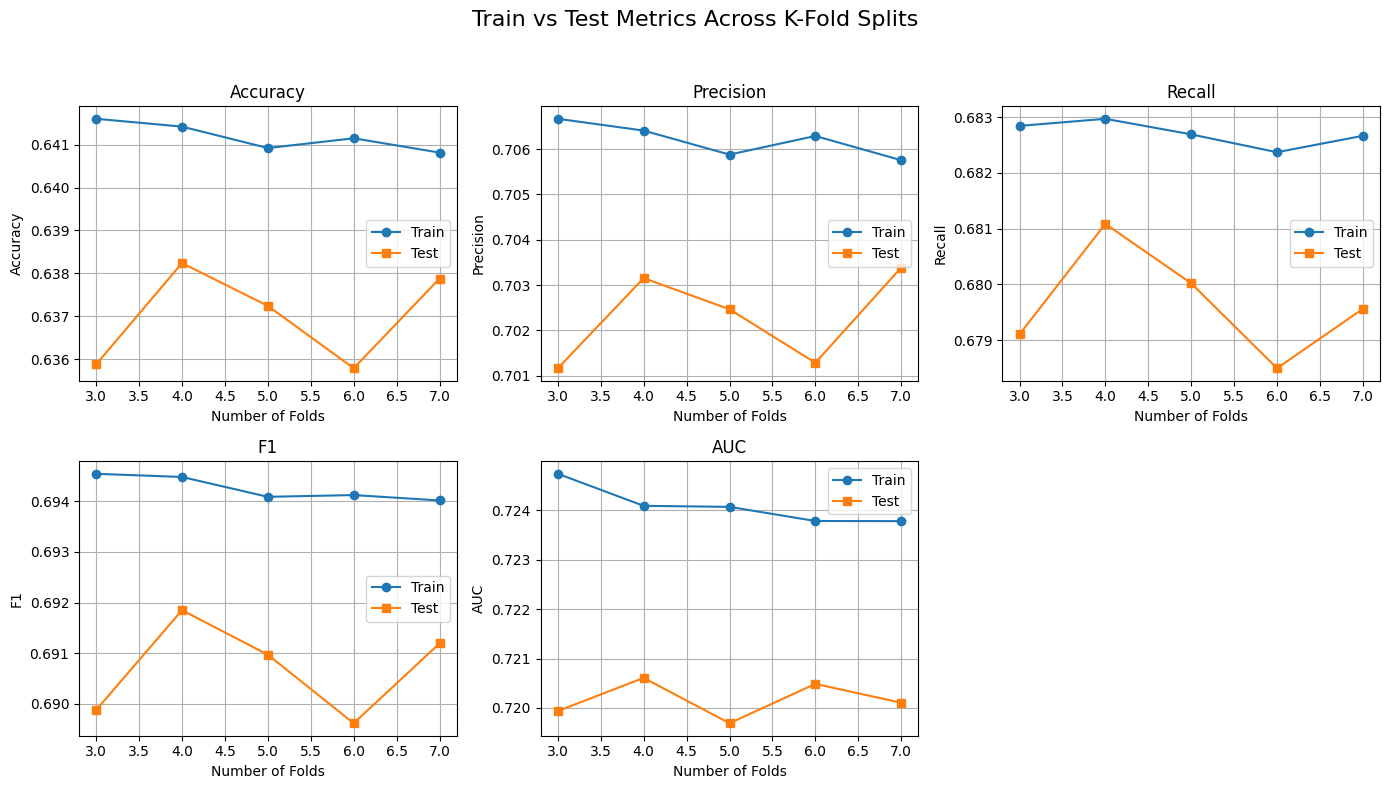

In [18]:
# Plotting function
def plot_all_metrics_in_grid(metrics, x_values):
    metric_names = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, name in enumerate(metric_names):
        ax = axes[i]
        ax.plot(x_values, metrics[f"Train {name}"], marker='o', label='Train')
        ax.plot(x_values, metrics[f"Test {name}"], marker='s', label='Test')
        ax.set_title(name)
        ax.set_xlabel("Number of Folds")
        ax.set_ylabel(name)
        ax.grid(True)
        ax.legend()

    if len(metric_names) < len(axes):
        axes[-1].axis("off")

    fig.suptitle("Train vs Test Metrics Across K-Fold Splits", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Call the plotting function
plot_all_metrics_in_grid(metrics_kfold, metrics_kfold['folds'])

### **Observations**
We select 4-fold cross validation as it performs slightly better than the other fold settings, even though the difference is marginal.

# **Final Model comparsion with Decision Tree, Random Forest Classifier**
* K=5, Features are Integer Encoded

In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# Separate features and target
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 5-fold CV
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Metrics storage
results = []

for model_name, model in models.items():

    acc, prec, rec, f1, auc = [], [], [], [], []

    for train_idx, test_idx in kf.split(X, y):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Encode + Scale
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        scaler = StandardScaler()

        X_train = X_train_raw.copy()
        X_test = X_test_raw.copy()

        X_train[categorical_cols] = encoder.fit_transform(X_train_raw[categorical_cols])
        X_test[categorical_cols] = encoder.transform(X_test_raw[categorical_cols])

        X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)[:, 1]

        auc.append(roc_auc_score(y_test, y_prob))

        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred, zero_division=0))
        rec.append(recall_score(y_test, y_pred, zero_division=0))
        f1.append(f1_score(y_test, y_pred, zero_division=0))

    results.append({
        'Model': model_name,
        'Test Accuracy': np.mean(acc),
        'Test Precision': np.mean(prec),
        'Test Recall': np.mean(rec),
        'Test F1': np.mean(f1),
        'Test AUC': np.mean(auc)
    })

# Results table
results_df = pd.DataFrame(results).round(4)
results_df


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Logistic Regression,0.6425,0.7066,0.6854,0.6957,0.7203
1,Decision Tree,0.6424,0.6985,0.7052,0.7018,0.6274
2,Random Forest,0.6620,0.7663,0.6241,0.6877,0.7393


### **Observation**
Random Forest peforms best among all when categorical features are integer encoded for k-Fold=5.

# **Final Model comparsion with Decision Tree, Random Forest Classifier**
* K=4, Features are One Hot Encoded

In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# Separate features and target
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4-fold CV
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for model_name, model in models.items():

    acc, prec, rec, f1, auc = [], [], [], [], []

    for train_idx, test_idx in kf.split(X, y):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # One-hot encode categorical
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        scaler = StandardScaler()

        X_train_cat = encoder.fit_transform(X_train_raw[categorical_cols])
        X_test_cat = encoder.transform(X_test_raw[categorical_cols])

        # Scale numeric
        X_train_num = scaler.fit_transform(X_train_raw[numerical_cols])
        X_test_num = scaler.transform(X_test_raw[numerical_cols])

        # Combine
        X_train = np.hstack([X_train_num, X_train_cat])
        X_test = np.hstack([X_test_num, X_test_cat])

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred, zero_division=0))
        rec.append(recall_score(y_test, y_pred, zero_division=0))
        f1.append(f1_score(y_test, y_pred, zero_division=0))
        auc.append(roc_auc_score(y_test, y_prob))

    results.append({
        'Model': model_name,
        'Test Accuracy': np.mean(acc),
        'Test Precision': np.mean(prec),
        'Test Recall': np.mean(rec),
        'Test F1': np.mean(f1),
        'Test AUC': np.mean(auc)
    })

# Results table
results_df = pd.DataFrame(results).round(4)
results_df


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Logistic Regression,0.6383,0.7033,0.6809,0.6919,0.7206
1,Decision Tree,0.6467,0.7018,0.7091,0.7054,0.6317
2,Random Forest,0.6532,0.7486,0.6310,0.6846,0.7327


### **Observation**
Random Forest peforms best among all when categorical features are one hot encoded for k-Fold=4.

# **Logistic Regression with KFolds for Multi-Class Classification**

# Car Evaluation Dataset Overview

The **Car Evaluation Dataset** comes from the automotive industry and is used to classify cars into four categories based on features like buying price, maintenance cost, seating capacity, luggage space, and safety.
The target classes are:

* `unacc`: Unacceptable
* `acc`: Acceptable
* `good`: Good
* `vgood`: Very Good


## Source:

Available via the UCI Machine Learning Repository:

* [UCI Dataset Page](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation)



## Features:

| Column Name | Description                         | Data Type     | Values / Categories             |
| ----------- | ----------------------------------- | ------------- | ------------------------------- |
| buying      | Buying price level                  | *Categorical* | `vhigh`, `high`, `med`, `low`   |
| maint       | Maintenance cost level              | *Categorical* | `vhigh`, `high`, `med`, `low`   |
| doors       | Number of doors                     | *Categorical* | `2`, `3`, `4`, `5more`          |
| persons     | Passenger capacity                  | *Categorical* | `2`, `4`, `more`                |
| lug\_boot   | Luggage boot size                   | *Categorical* | `small`, `med`, `big`           |
| safety      | Safety rating                       | *Categorical* | `low`, `med`, `high`            |
| class       | **Target**: Car acceptability class | *Categorical* | `unacc`, `acc`, `good`, `vgood` |


# **Loading the dataset**

In [31]:
import pandas as pd

# Define column names based on dataset description
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


df = pd.read_csv('car_v1.data', header=None, names=columns)


df


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


# **Checking for missing values**

In [33]:
df.isna().sum()


,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [34]:
(df == '').sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [35]:
df.apply(lambda x: x.astype(str).str.lower().isin(['none', 'null', 'na','?'])).sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


# **Displaying unique values of categorical columns**

In [36]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {unique_vals}")
    print('------------------------------------------------')

buying (4 unique): ['vhigh' 'high' 'med' 'low']
------------------------------------------------
maint (4 unique): ['vhigh' 'high' 'med' 'low']
------------------------------------------------
doors (4 unique): ['2' '3' '4' '5more']
------------------------------------------------
persons (3 unique): ['2' '4' 'more']
------------------------------------------------
lug_boot (3 unique): ['small' 'med' 'big']
------------------------------------------------
safety (3 unique): ['low' 'med' 'high']
------------------------------------------------
class (4 unique): ['unacc' 'acc' 'vgood' 'good']
------------------------------------------------


# **Label Count for target variable**

class
unacc    0.700231
acc      0.222222
good     0.039931
vgood    0.037616
Name: proportion, dtype: float64


<Axes: xlabel='class'>

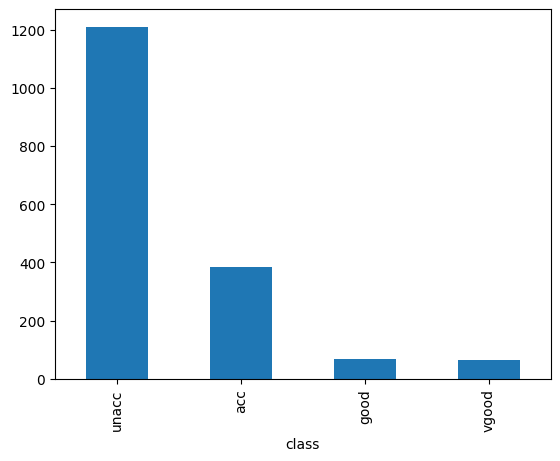

In [37]:
print(df['class'].value_counts(normalize=True))
df['class'].value_counts().plot(kind='bar')

# **Optimal Number of KFolds (value of K) using Using Logistic Regression and Categorical features: Integer Encoded**

We use **StratifiedKFold** to ensure that each fold has approximately the same proportion of class labels as the full dataset, and we evaluate fold counts in the range **3 to 10** to identify the optimal choice.

In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Separate features and target
# Drop 'ID' column and isolate features and target
X = df.drop(['class'], axis=1)  # Features (excluding ID and target)
y = df['class']                       # Target column
                     # Target column


# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


fold_values = [3,4, 5,6,7,8,9,10 ]  # Varying K-Fold splits


# Initialize metrics dictionary
metrics_kfold = {
    'folds': [],
    'Train Accuracy': [], 'Test Accuracy': [],
    'Train Precision': [], 'Test Precision': [],
    'Train Recall': [], 'Test Recall': [],
    'Train F1': [], 'Test F1': [],
    'Train AUC': [], 'Test AUC': []
}

# Loop over different fold counts
for n_folds in fold_values:
    train_acc, test_acc = [], []
    train_prec, test_prec = [], []
    train_rec, test_rec = [], []
    train_f1, test_f1 = [], []
    train_auc, test_auc = [], []

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(X, y):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Encode + Scale
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        #scaler = StandardScaler()

        X_train = X_train_raw.copy()
        X_test = X_test_raw.copy()

        X_train[categorical_cols] = encoder.fit_transform(X_train_raw[categorical_cols])
        X_test[categorical_cols] = encoder.transform(X_test_raw[categorical_cols])

        #X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        #X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

        # Train LR
        model= LogisticRegression()
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_prob = model.predict_proba(X_train)
        y_test_prob = model.predict_proba(X_test)

        # Metrics
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

        train_prec.append(precision_score(y_train, y_train_pred, zero_division=0,average='macro'))
        test_prec.append(precision_score(y_test, y_test_pred, zero_division=0,average='macro'))

        train_rec.append(recall_score(y_train, y_train_pred, zero_division=0,average='macro'))
        test_rec.append(recall_score(y_test, y_test_pred, zero_division=0,average='macro'))

        train_f1.append(f1_score(y_train, y_train_pred, zero_division=0,average='macro'))
        test_f1.append(f1_score(y_test, y_test_pred, zero_division=0,average='macro'))

        train_auc.append(roc_auc_score(y_train, y_train_prob,multi_class='ovr'))
        test_auc.append(roc_auc_score(y_test, y_test_prob,multi_class='ovr'))

    # Store average metrics
    metrics_kfold['folds'].append(n_folds)
    metrics_kfold['Train Accuracy'].append(np.mean(train_acc))
    metrics_kfold['Test Accuracy'].append(np.mean(test_acc))
    metrics_kfold['Train Precision'].append(np.mean(train_prec))
    metrics_kfold['Test Precision'].append(np.mean(test_prec))
    metrics_kfold['Train Recall'].append(np.mean(train_rec))
    metrics_kfold['Test Recall'].append(np.mean(test_rec))
    metrics_kfold['Train F1'].append(np.mean(train_f1))
    metrics_kfold['Test F1'].append(np.mean(test_f1))
    metrics_kfold['Train AUC'].append(np.mean(train_auc))
    metrics_kfold['Test AUC'].append(np.mean(test_auc))


import pandas as pd

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_kfold)

# Optional: round for readability
metrics_df = metrics_df.round(4)

# Print all metrics
metrics_df[['folds','Test Accuracy','Test Precision','Test Recall','Test F1','Test AUC']]









,folds,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,3,0.6921,0.3630,0.3228,0.3253,0.7850
1,4,0.6898,0.3758,0.3278,0.3311,0.7877
2,5,0.6898,0.3554,0.3251,0.3257,0.7900
3,6,0.6904,0.3522,0.3213,0.3205,0.7881
4,7,0.6898,0.3540,0.3237,0.3216,0.7915
5,8,0.6921,0.3514,0.3259,0.3236,0.7887
6,9,0.6933,0.3320,0.3214,0.3142,0.7867
7,10,0.6904,0.3655,0.3253,0.3252,0.7890


### **Observations**

1. **Integer encoding gives weak performance** for this fully categorical car dataset, as reflected by low precision, recall, and F1 scores despite moderate accuracy.

2. **Accuracy remains capped around 69 percent**, while nearly **70 percent of samples belong to a single class**, indicating that the model is unable to learn meaningful patterns beyond the class distribution.

3. **Changing the number of folds has negligible impact**, showing stable but consistently weak performance across different cross validation settings.


# **Optimal Number of KFolds (value of K) using Using Logistic Regression and Categorical features: One Hot Encoded**

We use **StratifiedKFold** to ensure that each fold has approximately the same proportion of class labels as the full dataset, and we evaluate fold counts in the range **3 to 10** to identify the optimal choice.

In [45]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Separate features and target
# Drop 'ID' column and isolate features and target
X = df.drop(['class'], axis=1)  # Features (excluding ID and target)
y = df['class']                       # Target column
                     # Target column


# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


fold_values = [3,4, 5,6,7,8,9,10 ]  # Varying K-Fold splits


# Initialize metrics dictionary
metrics_kfold = {
    'folds': [],
    'Train Accuracy': [], 'Test Accuracy': [],
    'Train Precision': [], 'Test Precision': [],
    'Train Recall': [], 'Test Recall': [],
    'Train F1': [], 'Test F1': [],
    'Train AUC': [], 'Test AUC': []
}

# Loop over different fold counts
for n_folds in fold_values:
    train_acc, test_acc = [], []
    train_prec, test_prec = [], []
    train_rec, test_rec = [], []
    train_f1, test_f1 = [], []
    train_auc, test_auc = [], []

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(X, y):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

        X_train_enc = encoder.fit_transform(X_train_raw[categorical_cols])
        X_test_enc  = encoder.transform(X_test_raw[categorical_cols])

        X_train = pd.DataFrame(
            X_train_enc,
            columns=encoder.get_feature_names_out(categorical_cols),
            index=X_train_raw.index
        )

        X_test = pd.DataFrame(
            X_test_enc,
            columns=encoder.get_feature_names_out(categorical_cols),
            index=X_test_raw.index
        )



        # Train LR
        model= LogisticRegression()
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_prob = model.predict_proba(X_train)
        y_test_prob = model.predict_proba(X_test)

        # Metrics
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

        train_prec.append(precision_score(y_train, y_train_pred, zero_division=0,average='macro'))
        test_prec.append(precision_score(y_test, y_test_pred, zero_division=0,average='macro'))

        train_rec.append(recall_score(y_train, y_train_pred, zero_division=0,average='macro'))
        test_rec.append(recall_score(y_test, y_test_pred, zero_division=0,average='macro'))

        train_f1.append(f1_score(y_train, y_train_pred, zero_division=0,average='macro'))
        test_f1.append(f1_score(y_test, y_test_pred, zero_division=0,average='macro'))

        train_auc.append(roc_auc_score(y_train, y_train_prob,multi_class='ovr'))
        test_auc.append(roc_auc_score(y_test, y_test_prob,multi_class='ovr'))

    # Store average metrics
    metrics_kfold['folds'].append(n_folds)
    metrics_kfold['Train Accuracy'].append(np.mean(train_acc))
    metrics_kfold['Test Accuracy'].append(np.mean(test_acc))
    metrics_kfold['Train Precision'].append(np.mean(train_prec))
    metrics_kfold['Test Precision'].append(np.mean(test_prec))
    metrics_kfold['Train Recall'].append(np.mean(train_rec))
    metrics_kfold['Test Recall'].append(np.mean(test_rec))
    metrics_kfold['Train F1'].append(np.mean(train_f1))
    metrics_kfold['Test F1'].append(np.mean(test_f1))
    metrics_kfold['Train AUC'].append(np.mean(train_auc))
    metrics_kfold['Test AUC'].append(np.mean(test_auc))


import pandas as pd

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_kfold)

# Optional: round for readability
metrics_df = metrics_df.round(4)

# Print all metrics
metrics_df[['folds','Test Accuracy','Test Precision','Test Recall','Test F1','Test AUC']]









,folds,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,3,0.9138,0.8302,0.7677,0.7825,0.9890
1,4,0.9126,0.8340,0.7657,0.7863,0.9891
2,5,0.9120,0.8225,0.7725,0.7827,0.9896
3,6,0.9109,0.8218,0.7660,0.7758,0.9901
4,7,0.9120,0.8278,0.7638,0.7767,0.9899
5,8,0.9120,0.8336,0.7623,0.7746,0.9902
6,9,0.9103,0.8173,0.7602,0.7686,0.9897
7,10,0.9080,0.8118,0.7575,0.7635,0.9896


Both 3-fold and 4-fold cross validation are comparable in performance, with 3-fold giving slightly higher accuracy while 4-fold shows marginally better balance across precision, so either can be reasonably selected.

### **Observations**
1. Performance is consistently high across all fold values, indicating strong and stable learning behavior under cross validation.

2. Differences across folds are minimal, showing that the model’s performance is not sensitive to the choice of fold count.
3. **One hot encoding is clearly beneficial**, as it enables the model to learn meaningful patterns from the categorical features and achieve strong overall performance.